In [3]:
import os
import synth_reader as sr
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [74]:
home = '/home/holman/StarLightv05/outputs/prefit/'
list_files = os.listdir(home)
list_files.sort()

print(len(list_files),' DONE!')


sr.FITS_conversion(id = list_files[15],home = home)

for e in list_files:
    sr.FITS_conversion(id = e,home = home)

150  DONE!
Fits file already in /home/holman/StarLightv05/outputs/prefit/004.CAL.MILES45.fits
Fits file already in /home/holman/StarLightv05/outputs/prefit/001.CAL.MILES45.fits
Fits file already in /home/holman/StarLightv05/outputs/prefit/001.CAL.MILES45.fits
Fits file saved in /home/holman/StarLightv05/outputs/prefit/001.GD1.MILES45.fits
Fits file saved in /home/holman/StarLightv05/outputs/prefit/001.GD2.MILES45.fits
Fits file already in /home/holman/StarLightv05/outputs/prefit/001.GD3.MILES45.fits
Fits file already in /home/holman/StarLightv05/outputs/prefit/001.GD3.MILES45.fits
Fits file already in /home/holman/StarLightv05/outputs/prefit/002.CAL.MILES45.fits
Fits file already in /home/holman/StarLightv05/outputs/prefit/002.CAL.MILES45.fits
Fits file saved in /home/holman/StarLightv05/outputs/prefit/002.GD1.MILES45.fits
Fits file saved in /home/holman/StarLightv05/outputs/prefit/002.GD2.MILES45.fits
Fits file saved in /home/holman/StarLightv05/outputs/prefit/002.GD3.MILES45.fits
Fit

ValueError: No se encontró la línea de cabecera que inicia con '# j'.

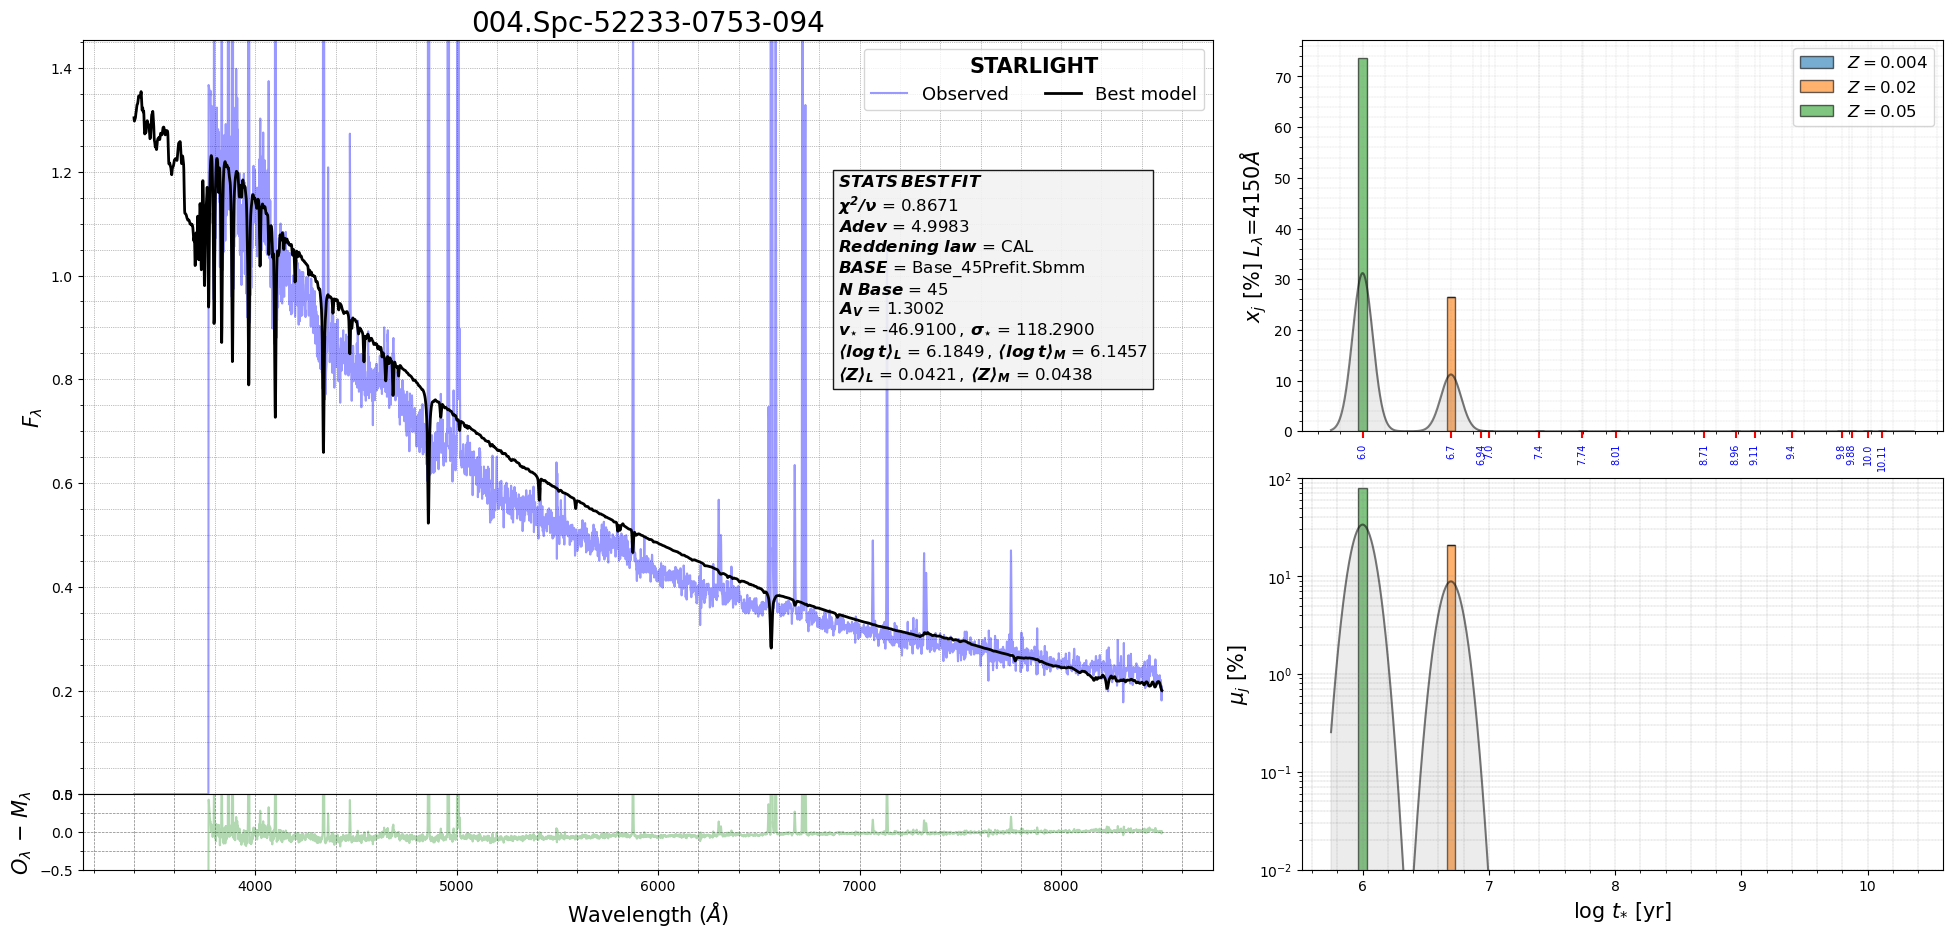

In [72]:
sr.spec_pop_STAR_mod(id = '004.CAL.MILES45.fits',
            home = '/home/holman/StarLightv05/outputs/prefit/')

# El numero 56 seria el perfecto para probar el fitter de las lineas y creacion de mascaras.

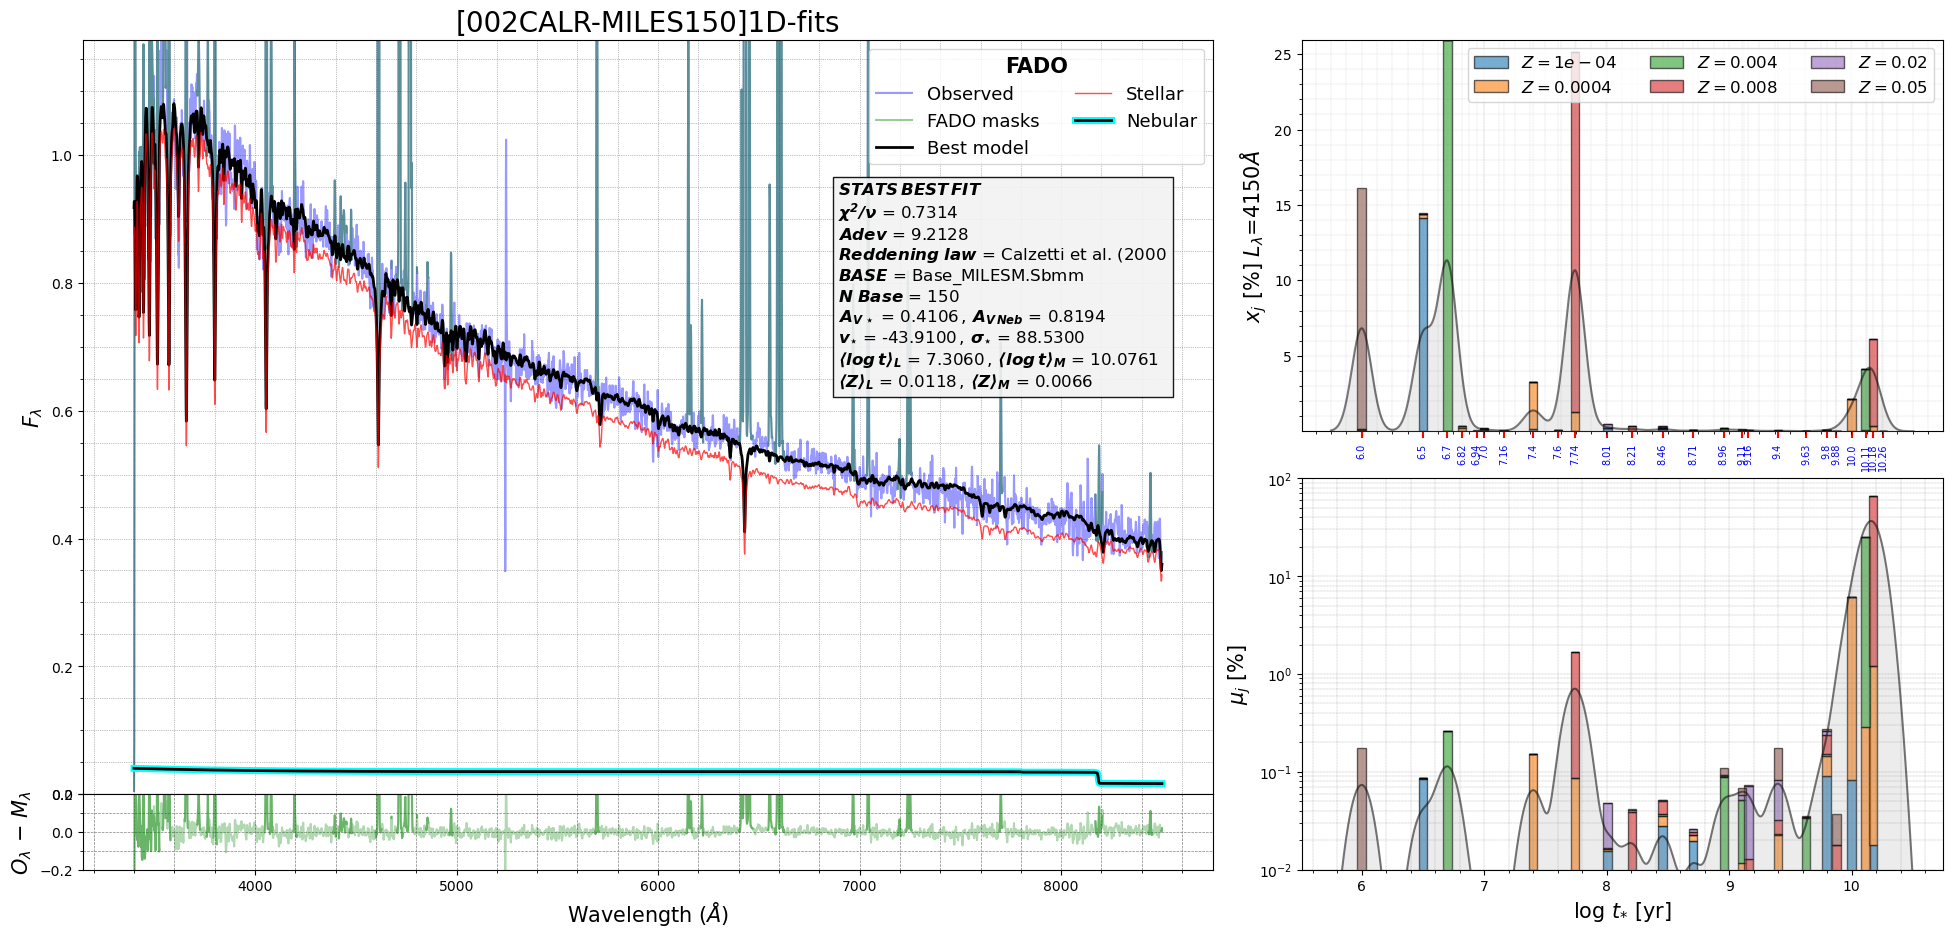

In [11]:
sr.spec_pop_FADO_mod(id = '002CALR.MILES150_1D.fits',
            home = '/home/holman/FADOv1b/o_FR4150/')

In [34]:
sr.FADO_merit_reader(id = '077CALR.MILES150_1D.fits',
            home = '/home/holman/FADOv1b/o_FR4150/')

[1.373, 18.605203215608892]

In [23]:
def merit_stats(path,title):
    spec_xxxx = [f for f in os.listdir(path) if f.endswith('_1D.fits')]
    spec_xxxx.sort()

    chi_cal,adev_cal = [],[]
    chi_gd1,adev_gd1 = [],[]
    chi_gd2,adev_gd2 = [],[]
    chi_gd3,adev_gd3 = [],[]

    for i in spec_xxxx:
        merits_ = sr.FADO_merit_reader(id = i,home = path)
        if 'CALR' in i:
            chi_cal.append(merits_[0])
            adev_cal.append(merits_[1])
        if 'GOR1' in i:
            chi_gd1.append(merits_[0])
            adev_gd1.append(merits_[1])
        if 'GOR2' in i:
            chi_gd2.append(merits_[0])
            adev_gd2.append(merits_[1])
        if 'GOR3' in i:
            chi_gd3.append(merits_[0])
            adev_gd3.append(merits_[1])

    merits = [chi_cal,chi_gd1,chi_gd2,chi_gd3,adev_cal,adev_gd1,adev_gd2,adev_gd3]
    nombres_columnas = [r'$\chi^2$',r'$\chi^2$',r'$\chi^2$',r'$\chi^2$',r'Adev',r'Adev',r'Adev',r'Adev']
    ext_laws = ['Calzetti','Gordon1','Gordon2','Gordon3','Calzetti','Gordon1','Gordon2','Gordon3']
    fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 8), sharey=False)
    fig.suptitle(title, fontsize=20, fontweight='bold')
    for i, ax in enumerate(axes.flat):
        ax.hist(merits[i], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
        data_stats = [np.mean(merits[i]),np.median(merits[i]),np.max(merits[i]),np.min(merits[i])]
        ax.axvline(data_stats[0], color='r', linestyle='dashed', linewidth=2, label=f'Mean: {data_stats[0]:.2f}')
        ax.axvline(data_stats[1], color='g', linestyle='dashed', linewidth=2, label=f'Median: {data_stats[1]:.2f}')
        ax.axvline(data_stats[2], color='b', linestyle='dashed', linewidth=2, label=f'Max: {data_stats[2]:.2f}')
        ax.axvline(data_stats[3], color='c', linestyle='dashed', linewidth=2, label=f'Min: {data_stats[3]:.2f}')
        ax.set_title(ext_laws[i])
        col_idx = i # % 4
        ax.set_xlabel(nombres_columnas[col_idx], fontsize=12, color='darkred')
        ax.legend()
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

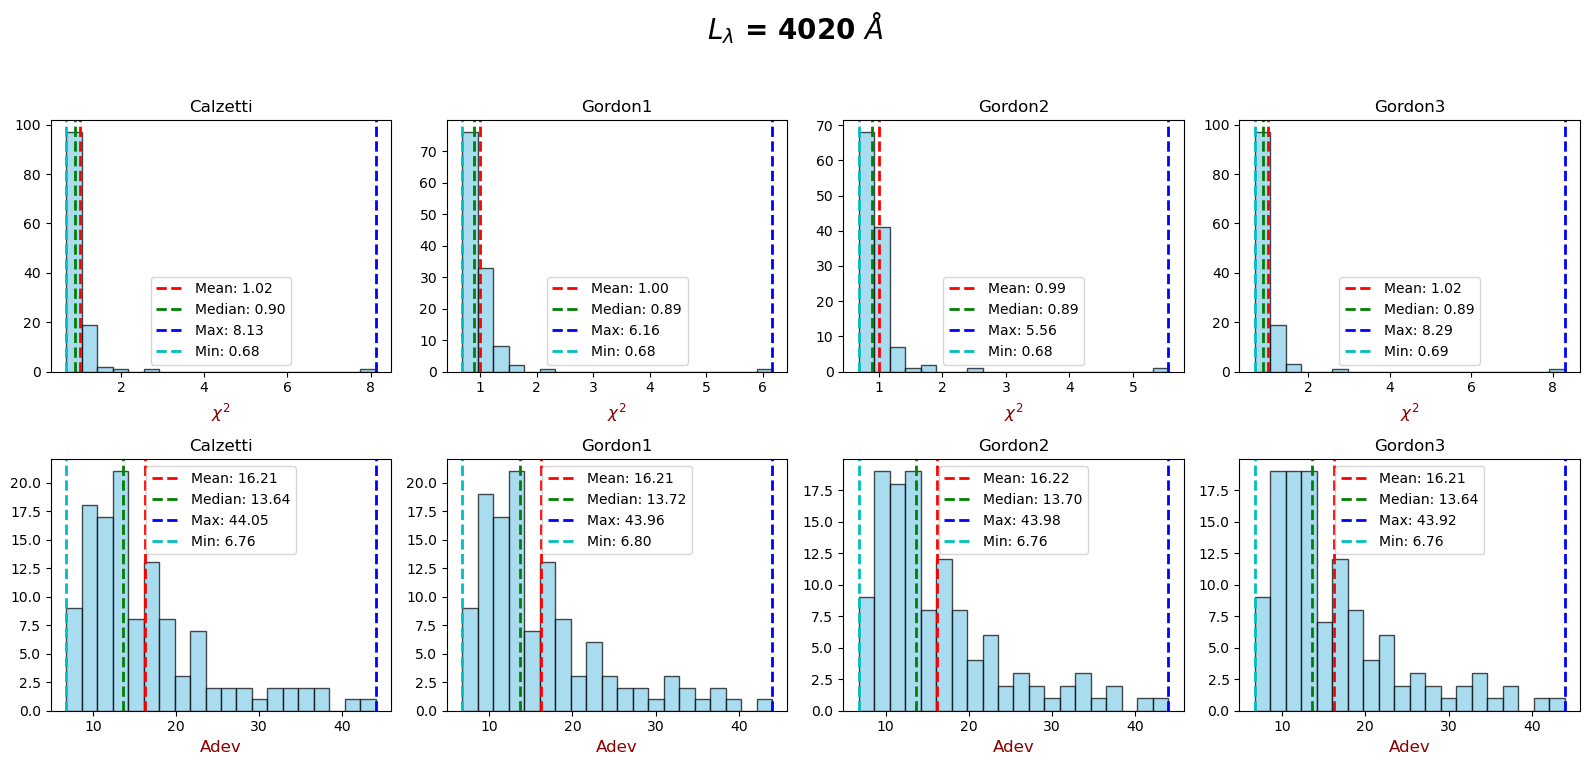

In [ ]:
merit_stats(path ='/home/holman/FADOv1b/o_FR4020/',
            title=r'$L_{\lambda}$ = 4020 $\AA$')

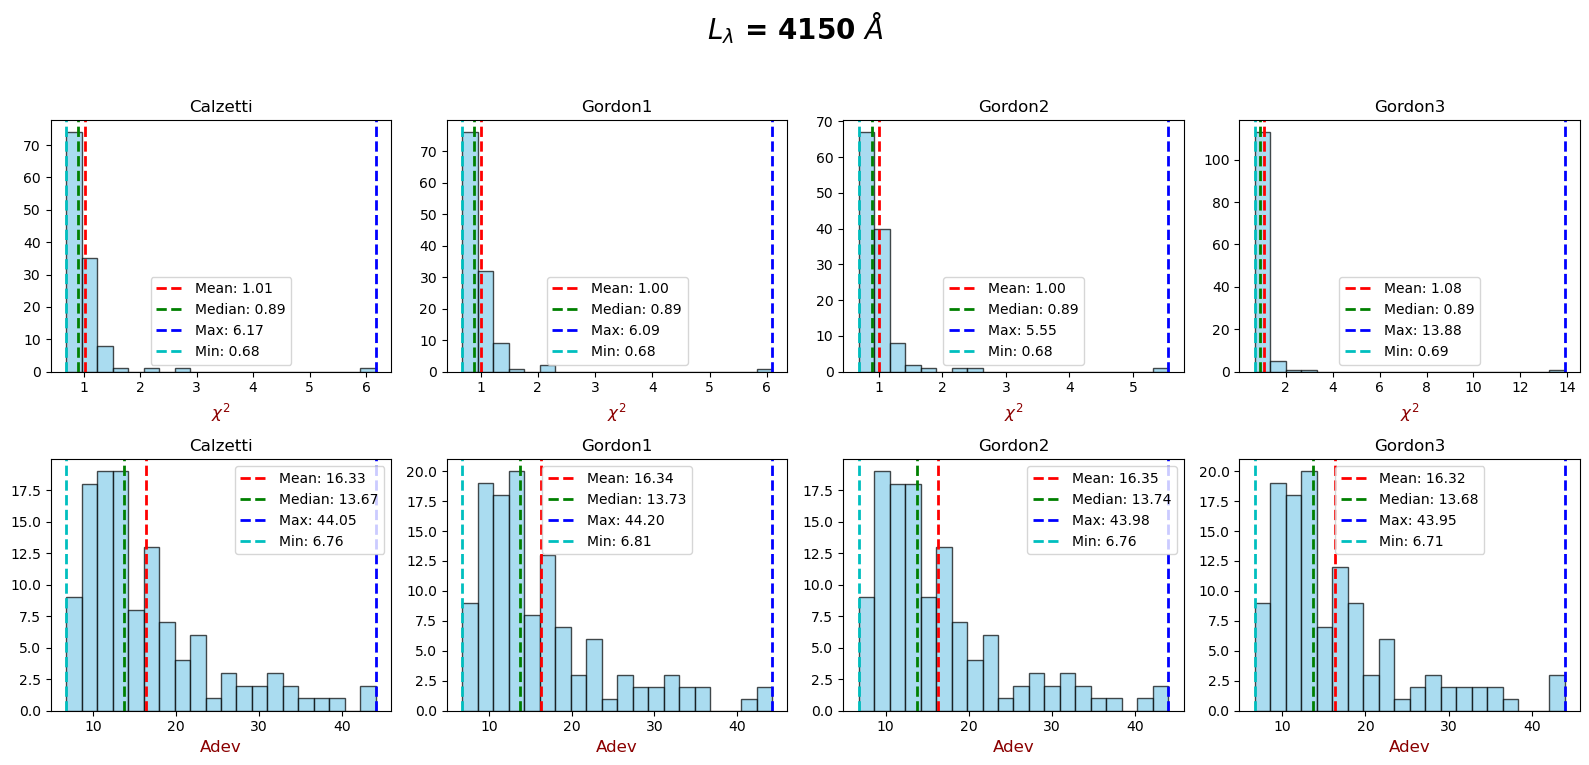

In [25]:
merit_stats(path ='/home/holman/FADOv1b/o_FR4150/',
            title=r'$L_{\lambda}$ = 4150 $\AA$')

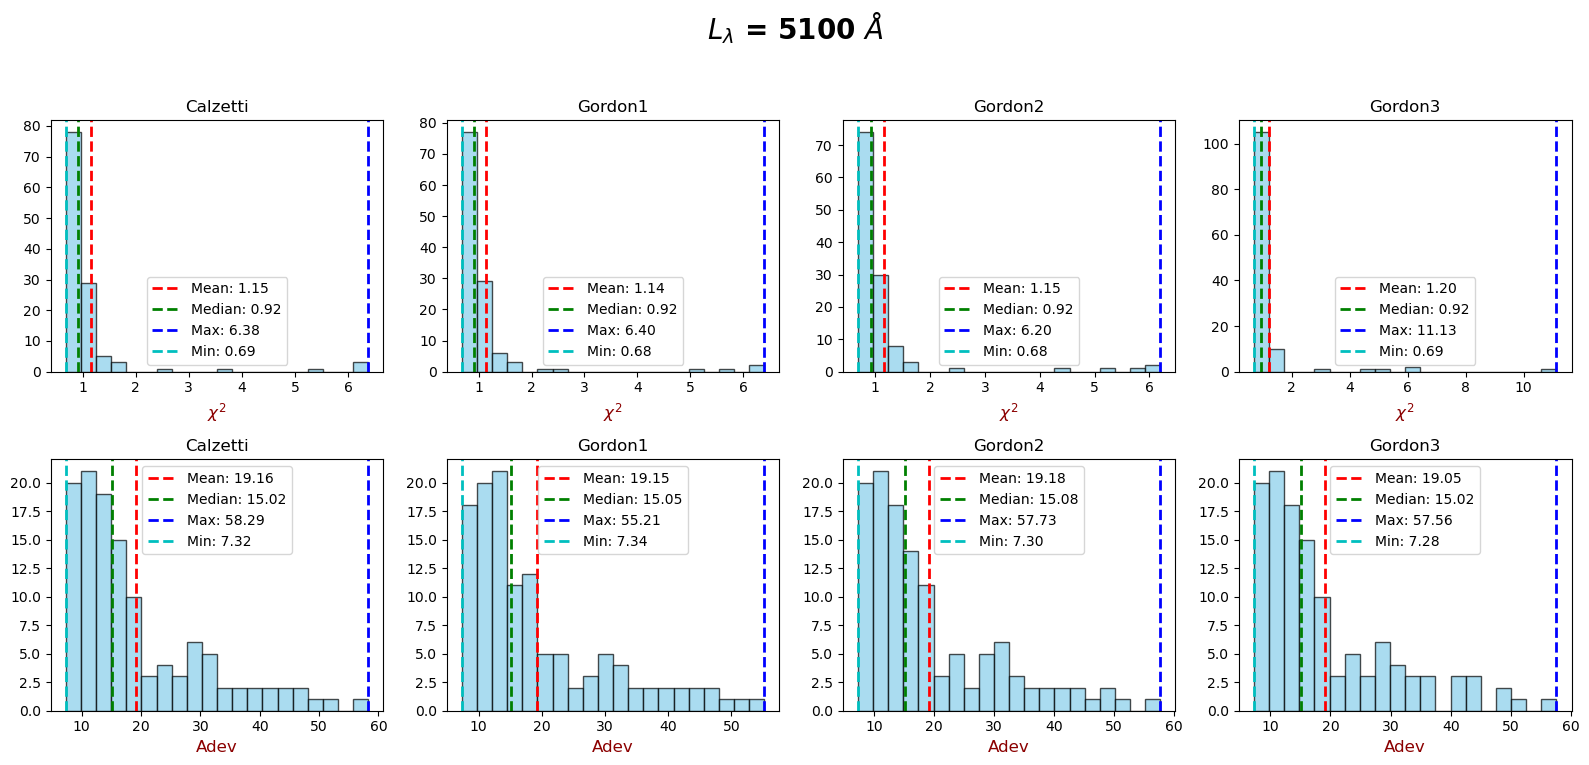

In [26]:
merit_stats(path ='/home/holman/FADOv1b/o_FR5100/',
            title=r'$L_{\lambda}$ = 5100 $\AA$')

In [27]:
storage_dir = os.path.join(os.path.expanduser("~"),'Data_storageHII/')
os.makedirs(storage_dir, exist_ok=True)
tex_folder = storage_dir + '/specTx_Tab5ID/'
tex_list = os.listdir(tex_folder)
#tex_list.remove('DOWNspec_listDR7.txt')
tex_list = sorted(tex_list)
len(tex_list)

121

In [28]:
lambda_range = np.arange(3400,8901,1)
fx_sum = []

for i in range(len(tex_list)):
    Df = pd.read_csv(tex_folder+tex_list[i], header=None, names=['lambda','Fx'], sep='\s+')
    for u in range(len(lambda_range)):
        tmp_df = Df[Df['lambda']==lambda_range[u]]
        if len(tmp_df) == 1:
            if i == 0:
                fx_sum.append(tmp_df['Fx'].iloc[0])
            else:
                fx_sum[u] = fx_sum[u] + tmp_df['Fx'].iloc[0]
        else:
            if i == 0:
                fx_sum.append(0)
            else:
                fx_sum[u] = fx_sum[u] + 0
        del tmp_df
    del Df
    #print(f'Added data from {tex_list[i]}')

    

In [29]:
len(fx_sum)

5501

[4150, 4125, 4175]

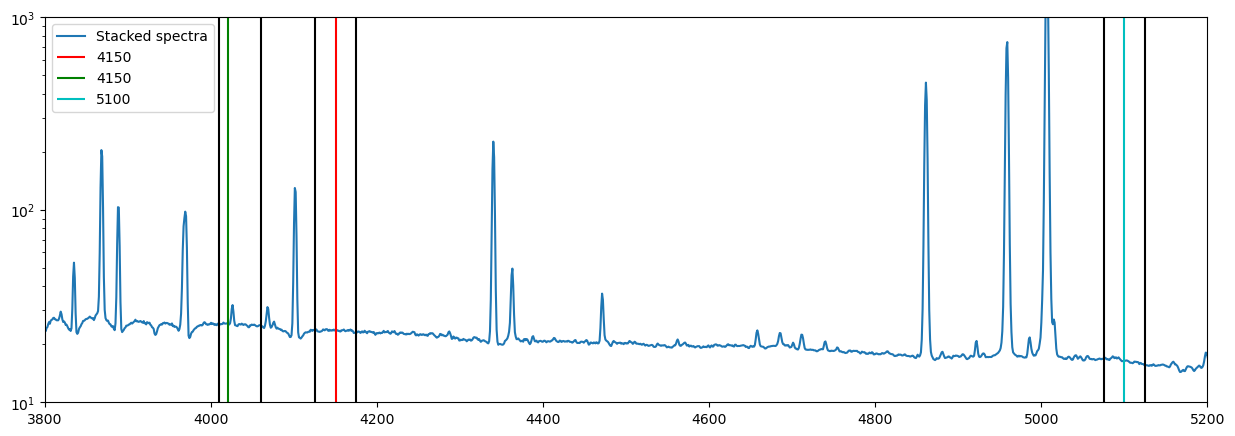

In [42]:
fig,ax = plt.subplots(figsize=(15, 5)) 

fx_ave = np.array(fx_sum) / 121
ax.plot(lambda_range,fx_ave,label = 'Stacked spectra')
ax.set_yscale('log')
ax.set_ylim([10e1,1e2])
ax.set_xlim([3800,5200])

l_norm = 4150

l_norms = [l_norm,l_norm-25,l_norm+25]

ax.vlines(l_norms[0],np.min(fx_ave),np.max(fx_ave),color = 'r',label = '4150')
ax.vlines(l_norms[1],np.min(fx_ave),np.max(fx_ave),color = 'k')
ax.vlines(l_norms[2],np.min(fx_ave),np.max(fx_ave),color = 'k')

ax.vlines(4020,np.min(fx_ave),np.max(fx_ave),color = 'g',label = '4150')
ax.vlines(4010,np.min(fx_ave),np.max(fx_ave),color = 'k')
ax.vlines(4060,np.min(fx_ave),np.max(fx_ave),color = 'k')


ax.vlines(5100,np.min(fx_ave),np.max(fx_ave),color = 'c',label = '5100')
ax.vlines(5075,np.min(fx_ave),np.max(fx_ave),color = 'k')
ax.vlines(5125,np.min(fx_ave),np.max(fx_ave),color = 'k')


#ax.vlines(4570,np.min(fx_ave),np.max(fx_ave),color = 'k')
#ax.vlines(4650,np.min(fx_ave),np.max(fx_ave),color = 'k')

ax.legend()

l_norms

In [1]:
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from astropy.io import fits
from astropy.table import Table

Intervalos finales enmascarados:
4490.94  4493.34  emission+spike
4855.28  4866.67  bad_region+emission
5000.13  5013.88  bad_region+emission
5415.02  5424.92  gap
6009.80  6011.12  spike
6555.63  6570.48  bad_region+emission
6577.72  6590.00  bad_region+emission


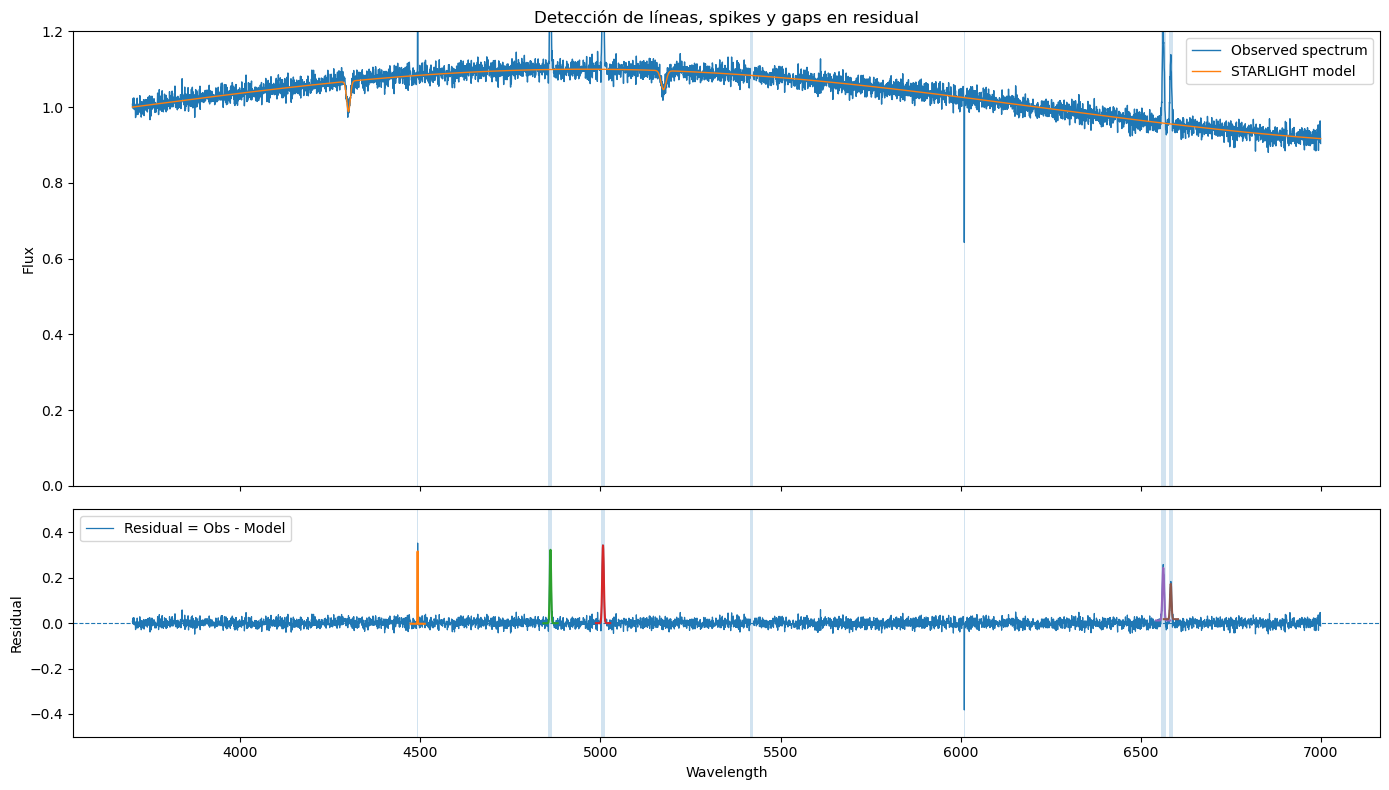

In [4]:
# ============================================================
# Utilidades básicas
# ============================================================

def robust_mad_std(x):
    """
    Estimación robusta de sigma usando MAD.
    """
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    return 1.4826 * mad


def gaussian(x, amp, mu, sigma, c):
    """
    Gaussiana + constante.
    """
    return amp * np.exp(-0.5 * ((x - mu) / sigma) ** 2) + c


def contiguous_regions(mask):
    """
    Convierte un boolean mask en intervalos contiguos [i0, i1].
    i1 es inclusivo.
    """
    mask = np.asarray(mask, dtype=bool)
    if mask.size == 0:
        return []

    d = np.diff(mask.astype(int))
    starts = np.where(d == 1)[0] + 1
    ends = np.where(d == -1)[0]

    if mask[0]:
        starts = np.r_[0, starts]
    if mask[-1]:
        ends = np.r_[ends, mask.size - 1]

    return list(zip(starts, ends))


def merge_intervals(intervals, padding=0.0):
    """
    Une intervalos traslapados o muy cercanos.
    intervals: lista de tuplas (lo, hi, label)
    padding: separación máxima permitida para fusionar
    """
    if len(intervals) == 0:
        return []

    # Ordenar por límite inferior
    intervals = sorted(intervals, key=lambda x: x[0])

    merged = [list(intervals[0])]
    for lo, hi, label in intervals[1:]:
        prev_lo, prev_hi, prev_label = merged[-1]

        if lo <= prev_hi + padding:
            merged[-1][1] = max(prev_hi, hi)
            # fusionar etiquetas
            labels = set(prev_label.split("+")) | set(label.split("+"))
            merged[-1][2] = "+".join(sorted(labels))
        else:
            merged.append([lo, hi, label])

    return [tuple(x) for x in merged]


# ============================================================
# Detección de líneas de emisión en el residual
# ============================================================

def fit_emission_line_gaussian(wave, residual, peak_idx,
                               window_angstrom=25.0,
                               min_sigma=0.4,
                               max_sigma=15.0):
    """
    Ajusta una gaussiana local alrededor de un pico del residual.
    Devuelve dict con parámetros del ajuste o None si falla.
    """
    mu0 = wave[peak_idx]

    sel = (wave >= mu0 - window_angstrom) & (wave <= mu0 + window_angstrom)
    x = wave[sel]
    y = residual[sel]

    if len(x) < 7 or not np.all(np.isfinite(y)):
        return None

    # Suposiciones iniciales
    c0 = np.median(y)
    amp0 = residual[peak_idx] - c0
    if amp0 <= 0:
        return None

    # Estimación inicial de sigma
    # si el muestreo es uniforme, esto funciona razonablemente bien
    dw = np.median(np.diff(wave))
    sigma0 = max(1.5 * dw, 1.0)

    p0 = [amp0, mu0, sigma0, c0]

    # Límites físicos razonables
    bounds = (
        [0.0, mu0 - 3.0, min_sigma, -np.inf],
        [np.inf, mu0 + 3.0, max_sigma, np.inf]
    )

    try:
        popt, pcov = curve_fit(gaussian, x, y, p0=p0, bounds=bounds, maxfev=20000)
        amp, mu, sigma, c = popt

        # métricas simples del ajuste
        yfit = gaussian(x, *popt)
        chi_like = np.nanmean((y - yfit) ** 2)

        return {
            "amp": amp,
            "mu": mu,
            "sigma": sigma,
            "continuum": c,
            "chi_like": chi_like,
            "xfit": x,
            "yfit": yfit,
            "window_mask": sel
        }
    except Exception:
        return None


def detect_emission_lines(wave, flux_obs, flux_model,
                          smooth_sigma_pix=1.2,
                          snr_peak=4.0,
                          prominence_sigma=3.0,
                          min_distance_pix=4,
                          fit_window_angstrom=25.0,
                          mask_nsigma=3.0):
    """
    Detecta líneas de emisión en el residual positivo y las ajusta con gaussianas.
    """
    residual = flux_obs - flux_model

    # Suavizado ligero para encontrar picos reales, sin perder demasiado detalle
    residual_smooth = gaussian_filter1d(residual, smooth_sigma_pix)

    sigma_res = robust_mad_std(residual)
    if not np.isfinite(sigma_res) or sigma_res <= 0:
        raise ValueError("No se pudo estimar el ruido robusto del residual.")

    # Encontrar picos positivos prominentes
    peaks, props = find_peaks(
        residual_smooth,
        height=snr_peak * sigma_res,
        prominence=prominence_sigma * sigma_res,
        distance=min_distance_pix
    )

    results = []
    intervals = []

    for p in peaks:
        fit = fit_emission_line_gaussian(
            wave, residual, p,
            window_angstrom=fit_window_angstrom
        )

        if fit is None:
            continue

        # filtro mínimo de calidad
        if fit["amp"] < snr_peak * sigma_res:
            continue

        lo = fit["mu"] - mask_nsigma * fit["sigma"]
        hi = fit["mu"] + mask_nsigma * fit["sigma"]

        results.append(fit)
        intervals.append((lo, hi, "emission"))

    return {
        "residual": residual,
        "sigma_res": sigma_res,
        "peaks": peaks,
        "fits": results,
        "intervals": intervals
    }


# ============================================================
# Detección de spikes / outliers angostos
# ============================================================

def detect_spikes(wave, flux_obs, flux_model,
                  spike_sigma=6.0,
                  max_width_pix=2,
                  grow_pix=1):
    """
    Detecta spikes positivos o negativos muy angostos en el residual.
    """
    residual = flux_obs - flux_model
    sigma_res = robust_mad_std(residual)

    if not np.isfinite(sigma_res) or sigma_res <= 0:
        raise ValueError("No se pudo estimar sigma robusto para spikes.")

    # Outliers absolutos
    bad = np.abs(residual) > spike_sigma * sigma_res

    regions = contiguous_regions(bad)
    intervals = []

    for i0, i1 in regions:
        width = i1 - i0 + 1
        if width <= max_width_pix:
            j0 = max(0, i0 - grow_pix)
            j1 = min(len(wave) - 1, i1 + grow_pix)
            intervals.append((wave[j0], wave[j1], "spike"))

    return {
        "sigma_res": sigma_res,
        "intervals": intervals
    }


# ============================================================
# Detección de gaps y regiones problemáticas
# ============================================================

def detect_gaps_and_bad_regions(wave, flux_obs, flux_model,
                                resid_sigma_thresh=4.0,
                                min_bad_run_pix=5,
                                grow_pix=2):
    """
    Detecta:
    - NaNs / infs
    - regiones donde el residual absoluto es persistentemente grande
    """
    residual = flux_obs - flux_model
    sigma_res = robust_mad_std(residual)

    invalid = (
        ~np.isfinite(wave) |
        ~np.isfinite(flux_obs) |
        ~np.isfinite(flux_model)
    )

    persistent_bad = np.abs(residual) > resid_sigma_thresh * sigma_res
    persistent_bad &= np.isfinite(residual)

    regions_invalid = contiguous_regions(invalid)
    regions_bad = contiguous_regions(persistent_bad)

    intervals = []

    # Gaps directos
    for i0, i1 in regions_invalid:
        j0 = max(0, i0 - grow_pix)
        j1 = min(len(wave) - 1, i1 + grow_pix)
        intervals.append((wave[j0], wave[j1], "gap"))

    # Regiones malas persistentes
    for i0, i1 in regions_bad:
        width = i1 - i0 + 1
        if width >= min_bad_run_pix:
            j0 = max(0, i0 - grow_pix)
            j1 = min(len(wave) - 1, i1 + grow_pix)
            intervals.append((wave[j0], wave[j1], "bad_region"))

    return {
        "sigma_res": sigma_res,
        "intervals": intervals
    }


# ============================================================
# Máscara global
# ============================================================

def build_starlight_mask(wave, flux_obs, flux_model,
                         emission_kwargs=None,
                         spike_kwargs=None,
                         gap_kwargs=None,
                         merge_padding_angstrom=2.0):
    """
    Corre toda la detección y genera:
    - intervalos fusionados
    - máscara booleana por pixel
    - detalles de cada subproceso
    """
    if emission_kwargs is None:
        emission_kwargs = {}
    if spike_kwargs is None:
        spike_kwargs = {}
    if gap_kwargs is None:
        gap_kwargs = {}

    out_em = detect_emission_lines(wave, flux_obs, flux_model, **emission_kwargs)
    out_sp = detect_spikes(wave, flux_obs, flux_model, **spike_kwargs)
    out_gp = detect_gaps_and_bad_regions(wave, flux_obs, flux_model, **gap_kwargs)

    intervals = out_em["intervals"] + out_sp["intervals"] + out_gp["intervals"]
    intervals = merge_intervals(intervals, padding=merge_padding_angstrom)

    final_mask = np.zeros_like(wave, dtype=bool)
    for lo, hi, _ in intervals:
        final_mask |= (wave >= lo) & (wave <= hi)

    return {
        "intervals": intervals,
        "mask": final_mask,
        "emission": out_em,
        "spikes": out_sp,
        "gaps": out_gp
    }


# ============================================================
# Exportar intervalos
# ============================================================

def save_mask_intervals_txt(filename, intervals, header=True):
    """
    Guarda intervalos en un txt simple:
    lambda_min lambda_max label
    """
    with open(filename, "w") as f:
        if header:
            f.write("# lambda_min  lambda_max  label\n")
        for lo, hi, label in intervals:
            f.write(f"{lo:.3f} {hi:.3f} {label}\n")


def save_mask_pixels_txt(filename, wave, mask, header=True):
    """
    Guarda la máscara por pixel:
    lambda mask
    """
    with open(filename, "w") as f:
        if header:
            f.write("# wavelength  mask\n")
        for w, m in zip(wave, mask):
            f.write(f"{w:.3f} {int(m)}\n")


# ============================================================
# Visualización
# ============================================================

def plot_mask_diagnostics(wave, flux_obs, flux_model, result,
                          figsize=(14, 8), title=None):
    """
    Muestra:
    1) espectro observado y modelo
    2) residual con regiones enmascaradas
    3) gaussianas ajustadas a líneas de emisión
    """
    residual = flux_obs - flux_model
    mask = result["mask"]
    intervals = result["intervals"]
    fits = result["emission"]["fits"]

    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True,
                             gridspec_kw={"height_ratios": [2, 1]})

    ax0, ax1 = axes

    # Panel superior: espectro y modelo
    ax0.plot(wave, flux_obs, lw=1.0, label="Observed spectrum")
    ax0.plot(wave, flux_model, lw=1.0, label="STARLIGHT model")

    for lo, hi, label in intervals:
        ax0.axvspan(lo, hi, alpha=0.20)

    ax0.set_ylabel("Flux")
    #ax0.set_yscale("log")
    ax0.set_ylim([0,1.2])
    ax0.legend()
    if title is not None:
        ax0.set_title(title)

    # Panel inferior: residual
    ax1.plot(wave, residual, lw=0.9, label="Residual = Obs - Model")
    ax1.axhline(0.0, ls="--", lw=0.8)

    for lo, hi, label in intervals:
        ax1.axvspan(lo, hi, alpha=0.20)

    # Mostrar gaussianas ajustadas
    for fit in fits:
        ax1.plot(fit["xfit"], fit["yfit"], lw=1.5)

    ax1.set_xlabel("Wavelength")
    ax1.set_ylabel("Residual")
    ax1.set_ylim([-0.5,0.5])
    ax1.legend()

    plt.tight_layout()
    plt.show()


# ============================================================
# Ejemplo de uso
# ============================================================

if __name__ == "__main__":
    # ========================================================
    # EJEMPLO SINTÉTICO
    # Reemplaza esta parte con tus arrays reales:
    # wave, flux_obs, flux_model
    # ========================================================

    np.random.seed(42)

    wave = np.linspace(3700, 7000, 5000)

    # "Modelo" sintético
    continuum = 1.0 + 0.1 * np.sin((wave - 3700) / 800.0)
    absorption = (
        -0.08 * np.exp(-0.5 * ((wave - 4300) / 5.0) ** 2)
        -0.05 * np.exp(-0.5 * ((wave - 5175) / 7.0) ** 2)
    )
    flux_model = continuum + absorption

    # Espectro observado = modelo + emisión + ruido + spikes + gap
    flux_obs = flux_model.copy()

    # Líneas de emisión sintéticas
    for amp, mu, sig in [
        (0.30, 4861.0, 2.0),   # Hbeta
        (0.35, 5007.0, 2.2),   # [OIII]
        (0.25, 6563.0, 2.5),   # Halpha
        (0.18, 6584.0, 2.2),   # [NII]
    ]:
        flux_obs += amp * np.exp(-0.5 * ((wave - mu) / sig) ** 2)

    # ruido
    flux_obs += np.random.normal(0, 0.015, size=wave.size)

    # spikes
    flux_obs[1200] += 0.35
    flux_obs[3500] -= 0.40

    # gap artificial
    flux_obs[2600:2612] = np.nan

    # ========================================================
    # Construir máscara
    # ========================================================
    result = build_starlight_mask(
        wave, flux_obs, flux_model,
        emission_kwargs=dict(
            smooth_sigma_pix=1.0,
            snr_peak=4.0,
            prominence_sigma=3.0,
            min_distance_pix=4,
            fit_window_angstrom=20.0,
            mask_nsigma=3.0
        ),
        spike_kwargs=dict(
            spike_sigma=6.0,
            max_width_pix=2,
            grow_pix=1
        ),
        gap_kwargs=dict(
            resid_sigma_thresh=4.0,
            min_bad_run_pix=5,
            grow_pix=2
        ),
        merge_padding_angstrom=2.0
    )

    print("Intervalos finales enmascarados:")
    for lo, hi, label in result["intervals"]:
        print(f"{lo:.2f}  {hi:.2f}  {label}")

    save_mask_intervals_txt("mask_intervals.txt", result["intervals"])
    save_mask_pixels_txt("mask_pixels.txt", wave, result["mask"])

    plot_mask_diagnostics(
        wave, flux_obs, flux_model, result,
        title="Detección de líneas, spikes y gaps en residual"
    )

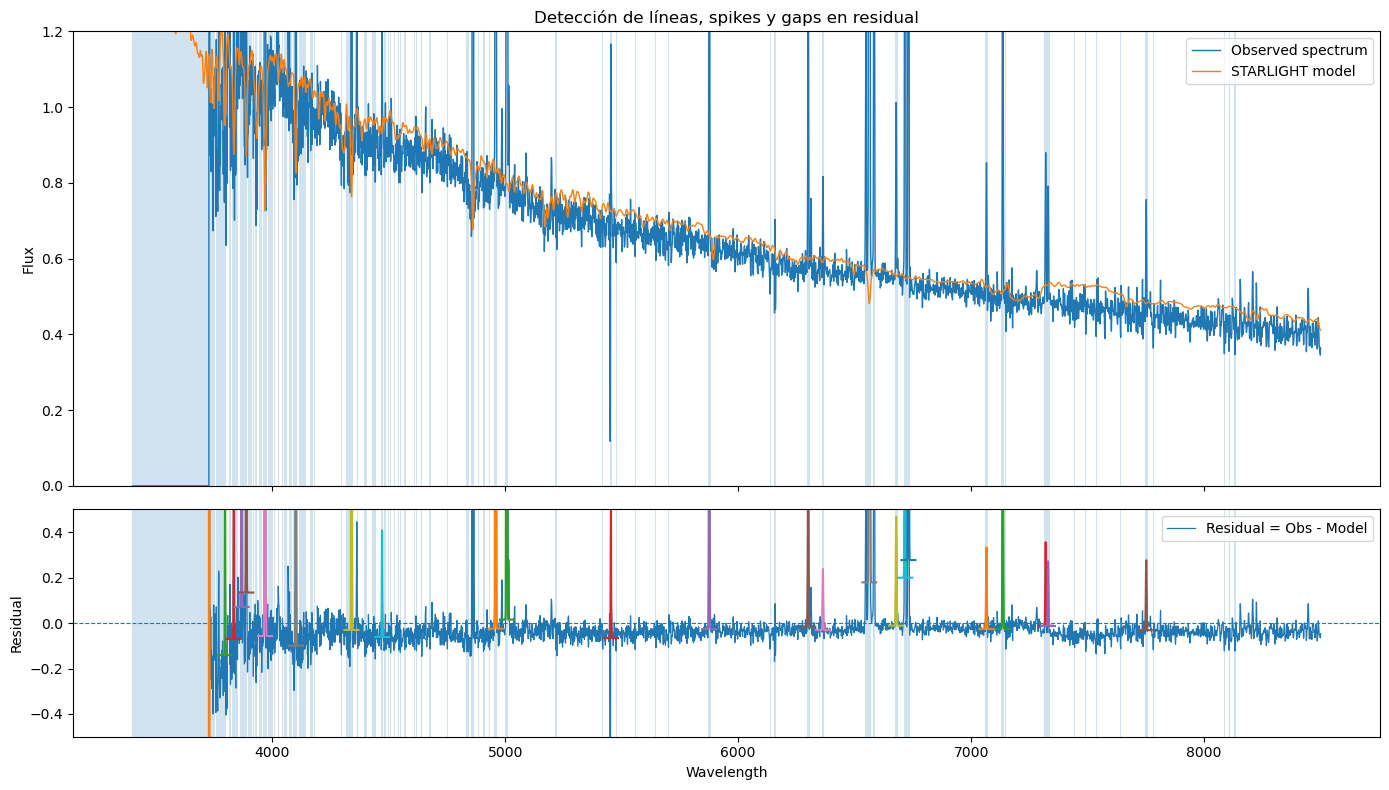

In [8]:
# ============================================================
# Ejemplo de uso
# ============================================================

if __name__ == "__main__":
    # ========================================================
    # EJEMPLO SINTÉTICO
    # Reemplaza esta parte con tus arrays reales:
    # wave, flux_obs, flux_model
    # ========================================================


    name = '/home/holman/StarLightv05/outputs/prefit/' + '002.CAL.MILES45.fits'


    if os.path.exists(name) != True:
        raise FileNotFoundError('File is not in folder. Try relocating the file or changing the name')
    
    FITS = fits.open(name)

    TABLE = Table.read(FITS[2])

    l_obs = TABLE['l_obs']
    f_obs = TABLE['f_obs']
    f_syn = TABLE['f_syn']

    wave = l_obs
    flux_obs = f_obs
    flux_model = f_syn







    # ========================================================
    # Construir máscara
    # ========================================================
    result = build_starlight_mask(
        wave, flux_obs, flux_model,
        emission_kwargs=dict(
            smooth_sigma_pix=1.0,
            snr_peak=5.0,
            prominence_sigma=3.0,
            min_distance_pix=4,
            fit_window_angstrom=30.0,
            mask_nsigma=4.0
        ),
        spike_kwargs=dict(
            spike_sigma=3.0,
            max_width_pix=2,
            grow_pix=2
        ),
        gap_kwargs=dict(
            resid_sigma_thresh=4.0,
            min_bad_run_pix=5,
            grow_pix=2
        ),
        merge_padding_angstrom=2.0
    )

    #print("Intervalos finales enmascarados:")
    #for lo, hi, label in result["intervals"]:
    #    print(f"{lo:.2f}  {hi:.2f}  {label}")

    save_mask_intervals_txt("mask_intervals.txt", result["intervals"])
    save_mask_pixels_txt("mask_pixels.txt", wave, result["mask"])

    plot_mask_diagnostics(
        wave, flux_obs, flux_model, result,
        title="Detección de líneas, spikes y gaps en residual"
    )